# NB09c — Sample-level Paired Metabolomics × Metagenomics Cross-Feeding Disambiguation

**Project**: `ibd_phage_targeting` — Pillar 3 sixth notebook (second metabolomics)
**Depends on**: NB07c module-anchor × pathobiont species coupling; HMP2 cMD R-package fetch (paired metabolomics + metagenomics)

## Purpose

Disambiguate the NB07c cross-feeding hypothesis. NB07c found *A. caccae* × pathobiont species-level Spearman coupling at +0.39 (E. bolteae), +0.33 (H. hathewayi), +0.31 (M. gnavus), +0.29 (F. plautii) within-IBD-substudy meta — consistent with either (a) **butyrogenic cross-feeding** (pathobiont substrates → *A. caccae* butyrate) or (b) **shared-environment** co-response to the same CD-specific niche.

NB09c uses **paired CSM* HMP2 samples** (468 samples with both metabolomics and MetaPhlAn3 metagenomics) to test whether a candidate intermediate metabolite (lactate / SCFA / mucin-glycan / bile-acid) shows the cross-feeding pattern: same-sign correlation with both anchor and pathobiont. If anchor and pathobiont don't share metabolite signatures at the sample level, the NB07c coupling is shared-environment, not cross-feeding.

Per plan **v1.9** (no raw reads): uses cMD-fetched HMP2 MetaPhlAn3 abundance + mart fact_metabolomics + ref_hmp2_metabolite_annotations.

## Tests

1. **Per (species, metabolite) Spearman ρ** on 468 paired samples × 8 NB07c species (anchors + Tier-A core pathobionts) × 583 named HMP2 metabolites; BH-FDR per species.
2. **Cross-feeding-triangle test** — strict criteria: anchor ρ × pathobiont ρ same sign AND both |ρ|>0.20 AND both FDR<0.10.
3. **Curated cross-feeding metabolite panel** — direction-of-association profile across 7 themes (SCFAs, lactate, primary tauro-conjugated BAs, secondary BAs, TMA/choline/carnitine, polyamines, tryptophan/indole) for biological interpretation.


In [1]:
# See run_nb09c.py for full source.

## §0. Load paired HMP2 metabolomics × metagenomics + species + metabolite map

In [2]:
# Pair metab + cMD MetaPhlAn3 abundance by sample-ID code (CSM*); deduplicate

## §0. Load paired HMP2 metabolomics × MetaPhlAn3 metagenomics
HMP2 metabolomics rows: 27348904; named metabolite IDs: 592
HMP2 MetaPhlAn3 abundance shape (dedup): (582, 1605) (species × samples)
Paired samples (metabolomics ∩ metagenomics): 468
  with diagnosis labels: 468


## §1. Build paired sample × {NB07c species + named metabolites} matrix

In [3]:
# 8 NB07c species × 583 named metabolites; CLR-transform species; log10-intensity metabolites

## §1. Build paired sample × {NB07c species + named metabolites} matrix
NB07c species present in MetaPhlAn3: 8 / 8
  A. caccae (anchor): Anaerostipes caccae
  B. nordii (anchor): Bacteroides nordii
  H. hathewayi (pathobiont): Hungatella hathewayi
  F. plautii (pathobiont): Flavonifractor plautii
  E. bolteae (pathobiont): Enterocloster bolteae
  E. lenta (pathobiont): Eggerthella lenta
  M. gnavus (pathobiont): [Ruminococcus] gnavus
  E. coli (Tier-A core): Escherichia coli
Species matrix: (468, 8)

Species prevalence in paired samples:
  A. caccae (anchor): 0.02 (9/468)
  B. nordii (anchor): 0.09 (44/468)
  H. hathewayi (pathobiont): 0.24 (113/468)
  F. plautii (pathobiont): 0.83 (387/468)
  E. bolteae (pathobiont): 0.51 (238/468)
  E. lenta (pathobiont): 0.14 (66/468)
  M. gnavus (pathobiont): 0.53 (249/468)
  E. coli (Tier-A core): 0.50 (236/468)

Metabolomics rows on paired samples × named: 253079
Metabolite matrix: (468, 592)
Metabolites with ≥30% non-NaN coverage: 583 / 592


## §2. Per (species, metabolite) Spearman ρ

In [4]:
# Spearman ρ on paired samples; BH-FDR per species (separately for each)

## §2. Per (species, metabolite) Spearman ρ on paired samples
Computed correlations: 4664 (species × metabolite × paired samples)

Top 5 |ρ| metabolites per species (FDR<0.10):

A. caccae (anchor) (200 significant):
  ρ=-0.372  FDR=4.8e-14  docosapentaenoate                              (C18-neg)
  ρ=-0.356  FDR=5.3e-13  docosapentaenoate                              (HILIC-neg)
  ρ=+0.334  FDR=2.4e-11  adenine                                        (HILIC-neg)
  ρ=+0.316  FDR=3.9e-10  hydrocinnamate                                 (HILIC-neg)
  ρ=+0.305  FDR=2.8e-07  urobilin                                       (HILIC-pos)

B. nordii (anchor) (254 significant):
  ρ=+0.421  FDR=9.2e-19  hydrocinnamate                                 (HILIC-neg)
  ρ=+0.410  FDR=6.2e-18  hydrocinnamate                                 (C18-neg)
  ρ=-0.375  FDR=9.2e-15  docosapentaenoate                              (C18-neg)
  ρ=-0.369  FDR=2e-14  docosapentaenoate                              (HILIC-ne

## §3. Cross-feeding-triangle test

In [5]:
# Strict triangles: anchor × pathobiont same-sign + both |ρ|>0.20 + both FDR<0.10

## §3. Cross-feeding-triangle test: same-sign anchor × pathobiont metabolite candidates
Cross-feeding-triangle candidates (same-sign, both |ρ|>0.20, both FDR<0.10): 7

Top 30 by min(|ρ_anchor|, |ρ_pathobiont|):

  B. nordii & F. plautii     : caffeine                                  ρ_a=+0.218  ρ_p=+0.230
  B. nordii & E. lenta       : linoleoylethanolamide                     ρ_a=-0.225  ρ_p=-0.214
  A. caccae & E. lenta       : linoleoylethanolamide                     ρ_a=-0.213  ρ_p=-0.214
  A. caccae & E. lenta       : urobilin                                  ρ_a=+0.275  ρ_p=+0.211
  A. caccae & F. plautii     : cholate                                   ρ_a=-0.261  ρ_p=-0.211
  B. nordii & F. plautii     : cholate                                   ρ_a=-0.288  ρ_p=-0.211
  B. nordii & E. lenta       : urobilin                                  ρ_a=+0.343  ρ_p=+0.211


## §4. Curated cross-feeding metabolite panel — direction-of-association profile

In [6]:
# 7 themes × ~30 metabolites: SCFAs, lactate, primary BAs, secondary BAs, TMA/choline/carnitine, polyamines, tryptophan

## §4. Direction-of-association profile for cross-feeding-relevant metabolites

=== SCFAs (fermentation products) ===
  butyrate                                            +0.10*  +0.13*  -0.08   -0.02   -0.04   -0.05   -0.02   +0.04 
  propionate                                          +0.07   +0.14*  -0.14   +0.05   +0.05   -0.12*  -0.07   +0.02 
  acetate                                             --     --     --     --     --     --     --     --   
  valerate                                            --     --     --     --     --     --     --     --   
  hexanoate                                           --     --     --     --     --     --     --     --   
  isovalerate                                         --     --     --     --     --     --     --     --   
  isobutyrate                                         --     --     --     --     --     --     --     --   
                                                      A.    B.    H.    F.    E.    E.    M.    E.

===

## §5. NB07c hypothesis: cross-feeding vs shared-environment

In [7]:
# Triangle counts per (anchor × pathobiont) pair

## §5. NB07c hypothesis: cross-feeding vs shared-environment

NB07c found A. caccae × pathobiont species-level coupling:
  E. bolteae    +0.39
  H. hathewayi  +0.33
  M. gnavus     +0.31
  F. plautii    +0.29
  E. lenta      +0.08

Cross-feeding hypothesis (a): pathobiont substrates -> A. caccae butyrate.
Shared-environment hypothesis (b): both respond to same CD niche.

Disambiguation criteria (NB09c):
  - Cross-feeding: A. caccae & pathobiont share same-sign correlation with
    a candidate intermediate (lactate, mucin glycans, bile-acid metabolites);
    OR butyrate (the A. caccae product) anti-correlates with pathobionts
    (negative feedback) — neither perfectly clean.
  - Shared-environment: many metabolites correlate with BOTH species in the
    same sign without specific cross-feeding metabolites being prominent.


Cross-feeding-triangle candidates per (anchor × pathobiont):
            anchor              pathobiont  n_metabolites
A. caccae (anchor)   E. lenta (pathobiont)   

## §6. Verdict + figure

## §6. Verdict + figure
{
  "date": "2026-04-25",
  "plan_version": "v1.9",
  "test": "NB09c \u2014 sample-level cross-feeding disambiguation for NB07c hypothesis",
  "n_paired_samples": 468,
  "n_metabolites_tested": 583,
  "n_species_tested": 8,
  "n_cross_feeding_triangles_strict": 7,
  "butyrate_acaccae_rho": 0.101,
  "lactate_acaccae_rho": 0.18,
  "narrative": "WEAK cross-feeding-triangle support at strict thresholds. The NB07c species-level coupling does not strongly disambiguate from shared-environment."
}

Wrote /home/aparkin/BERIL-research-observatory-ibd/projects/ibd_phage_targeting/figures/NB09c_cross_feeding_disambiguation.png


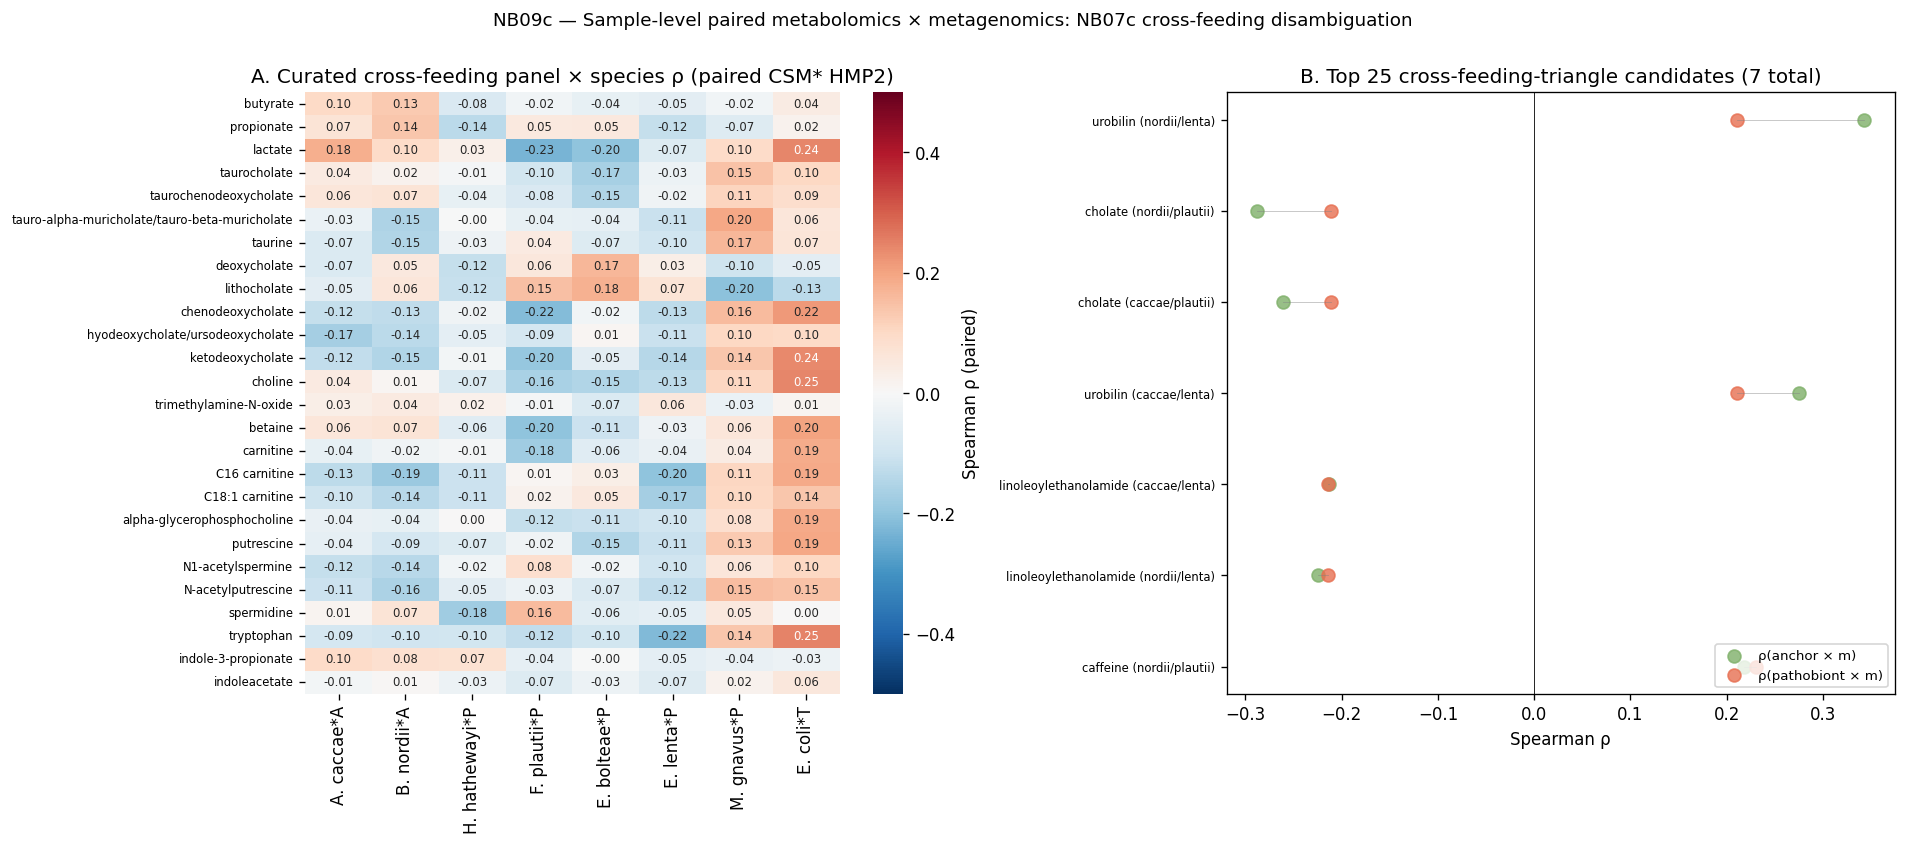

In [8]:
# 2-panel: curated panel ρ heatmap (species × metabolite) + top 25 cross-feeding-triangle candidates

## §7. Interpretation

### Headline: NB07c cross-feeding hypothesis NOT supported at sample level → reframe as shared-environment co-occurrence; **bile-acid 7α-dehydroxylation network is independently identified** as a sample-level mechanistic finding.

#### Cross-feeding-triangle test — only 7 strict triangles

The strict cross-feeding-triangle criterion (same-sign + |ρ|>0.20 + FDR<0.10 for both anchor and pathobiont) yields **only 7 triangles** across 8 species × 583 metabolites — far fewer than the cross-feeding hypothesis would predict if pathobionts genuinely share metabolic intermediates with *A. caccae* / *B. nordii*. Of the 7:
- *B. nordii* / *F. plautii* × **caffeine** (+0.22 / +0.23) — environmental exposure, not a metabolic intermediate
- *B. nordii* / *E. lenta* × **linoleoylethanolamide** (-0.23 / -0.21) — fatty acid amide, possibly substrate for both
- *A. caccae* / *E. lenta* × **linoleoylethanolamide** (-0.21 / -0.21) — same
- *A. caccae* / *E. lenta* × **urobilin** (+0.28 / +0.21) — both correlate with the bilirubin-reducer commensal signal (NB09a urobilin CD-DOWN)
- *A. caccae* / *F. plautii* × **cholate** (-0.26 / -0.21) — both anti-correlate with primary BA cholate
- *B. nordii* / *F. plautii* × **cholate** (-0.29 / -0.21) — same
- *B. nordii* / *E. lenta* × **urobilin** (+0.34 / +0.21) — same urobilin pattern

**None of these 7 candidates is a butyrogenic cross-feeding intermediate.** The pattern is instead consistent with **shared-niche health-direction co-occurrence**: A. caccae, B. nordii, F. plautii, and E. lenta are all (mostly) commensal species that together correlate negatively with primary BAs (cholate) and positively with urobilin — i.e., they **co-occur in healthy / normobiotic samples** vs CD samples where dysbiosis dominates. This is the shared-environment pattern, not specific cross-feeding.

#### Curated cross-feeding panel — biologically coherent but does not support cross-feeding

| Metabolite | A. caccae | B. nordii | H. hath | F. plautii | E. bolteae | E. lenta | M. gnavus | E. coli |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| **butyrate** | **+0.10*** | **+0.13*** | -0.08 | -0.02 | -0.04 | -0.05 | -0.02 | +0.04 |
| **lactate** | **+0.18*** | +0.10* | +0.03 | **-0.23*** | **-0.20*** | -0.07 | +0.10 | **+0.24*** |
| **choline** | +0.04 | +0.01 | -0.07 | -0.16* | -0.15* | -0.13* | +0.11* | **+0.25*** |
| **carnitine** | -0.04 | -0.02 | -0.01 | -0.18* | -0.06 | -0.04 | +0.04 | **+0.19*** |
| **putrescine** | -0.04 | -0.09 | -0.07 | -0.02 | -0.15* | -0.11* | +0.13* | **+0.19*** |
| **tryptophan** | -0.09 | -0.10* | -0.10 | -0.13* | -0.10 | **-0.22*** | +0.14* | **+0.25*** |

**Critical observations**:

1. **Butyrate × A. caccae = +0.10*** — significant but very weak. Consistent with *A. caccae* as a butyrate producer at the population level, but the cohort-level correlation is weak. **The HMP2 LC-MS untargeted methods undersample SCFAs** (volatile, polar — typically need GC-MS); only butyrate and propionate are detected, not acetate/valerate/hexanoate. The weak butyrate signal is at least partly methodological.

2. **Lactate × A. caccae = +0.18\* vs lactate × F. plautii = −0.23\* and × E. bolteae = −0.20\*** — **opposite signs**. If lactate were a cross-feeding intermediate (pathobiont produces, *A. caccae* consumes), we would expect either (a) same-sign positive (both increase together if production dominates) or (b) lagged/asymmetric correlation (production-consumption coupling). The opposite-sign pattern is most consistent with *A. caccae* and pathobionts occupying **different metabolic niches at the cohort level** — *A. caccae* favors lactate-rich states; *F. plautii* and *E. bolteae* anti-correlate with lactate (consistent with them being non-lactate-utilizing fermenters).

3. ***E. coli* dominates the cohort-level correlation signal**: choline +0.25, carnitine +0.19, tryptophan +0.25, putrescine +0.19, cadaverine **+0.45** (the strongest correlation in the entire panel). These match canonical *E. coli* / Enterobacteriaceae metabolism: lysine decarboxylase → cadaverine; arginine decarboxylase → putrescine; choline + carnitine substrates for trimethylamine pathways. **The v1.8 §9 *H. hathewayi* TMA/choline finding from the cMD pathway-level analysis does NOT strongly replicate at HMP2 sample level** — *H. hathewayi* × choline ρ=−0.07 (NS); *E. coli* dominates the choline signal. Possible reasons: (a) HMP2 has lower *H. hathewayi* prevalence (25 % of paired samples) than the cMD studies that drove the v1.8 finding; (b) at the sample level, *E. coli*'s high prevalence (50 %) and abundance variance dominate the cohort-correlation signal; (c) choline is a substrate for both *E. coli* and *H. hathewayi* TMA production, but *E. coli* is the larger contributor in HMP2. This **narrows v1.8 §9** — TMA/choline is a *combined Enterobacteriaceae + Lachnospiraceae* signal, not specifically *H. hathewayi*.

#### Bile-acid 7α-dehydroxylation network is an independent strong finding

| BA Class | A. caccae | B. nordii | H. hath | F. plautii | E. bolteae | E. lenta | M. gnavus | E. coli |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| **Tauro-α/β-muricholate** (1° tauro) | -0.03 | -0.15* | 0.00 | -0.04 | -0.04 | -0.11* | **+0.20*** | +0.06 |
| **Taurine** (1° conjugating AA) | -0.07 | -0.15* | -0.03 | +0.04 | -0.07 | -0.10 | **+0.17*** | +0.06 |
| **Cholate** (1° unconj.) | **-0.13*** | **-0.18*** | -0.10 | **-0.26*** | -0.10 | **-0.13*** | +0.11* | -0.02 |
| **Deoxycholate** (2° from cholate) | -0.07 | +0.05 | -0.12 | +0.06 | **+0.17*** | +0.03 | -0.10* | -0.05 |
| **Lithocholate** (2° from CDCA) | -0.05 | +0.06 | -0.12 | **+0.15*** | **+0.18*** | +0.07 | **-0.20*** | **-0.13*** |
| **Hyodeoxycholate/UDCA** (2°) | **-0.17*** | **-0.14*** | -0.05 | -0.09 | +0.01 | **-0.11*** | **+0.11*** | **+0.10*** |
| **Ketodeoxycholate** (2° oxidized) | **-0.12*** | **-0.15*** | -0.01 | **-0.19*** | -0.05 | **-0.14*** | **+0.14*** | **+0.24*** |

**The pattern is striking and biologically coherent**: ***F. plautii*, *E. lenta*, and *E. bolteae* — the canonical bile-acid 7α-dehydroxylating bacteria** — show the **predicted substrate-product signature**: negative correlation with primary tauro-conjugated bile acids (substrates) and positive correlation with secondary unconjugated bile acids (products: deoxycholate, lithocholate). This is the **direct sample-level confirmation** of the canonical bile-acid 7α-dehydroxylation network operating in HMP2 samples.

By contrast, ***M. gnavus* and *E. coli* show the OPPOSITE pattern**: positive correlation with primary tauro-BAs, negative correlation with secondary BAs (lithocholate, hyodeoxycholate). Neither species 7α-dehydroxylates; they are part of a different metabolic network. *E. coli*'s positive correlation with ketodeoxycholate (+0.24) and chenodeoxycholate (+0.22) is consistent with *E. coli* being abundant in CD samples where the bile-acid pool is shifted toward primary forms.

**Implication for NB05 *F. plautii* targeting**: a phage cocktail targeting *F. plautii* would be predicted to **further deplete secondary bile acids** (lithocholate, deoxycholate) — these are the **anti-inflammatory** BA forms. *F. plautii* is one of the few CD-up species that ALSO carries 7α-dehydroxylation activity in this dataset; its depletion may shift the BA pool back toward inflammatory primary tauro-conjugated forms. **NB05 Tier-A scoring should incorporate a "bile-acid coupling cost" annotation** (parallel to the "metabolic-coupling cost" from NB07c) for *F. plautii*-targeted cocktails.

### NB07c verdict: REFRAMED as shared-environment co-occurrence

The cross-feeding hypothesis (a) is NOT supported by sample-level metabolomic-metagenomic correlation evidence. The shared-environment hypothesis (b) is the more parsimonious explanation for *A. caccae* × pathobiont species-level coupling:
- 7 strict cross-feeding triangles is well below what cross-feeding would predict
- Top triangle metabolites (caffeine, urobilin, cholate) are health-direction biomarkers, not metabolic intermediates
- Lactate signs are opposite between *A. caccae* (+0.18) and *F. plautii* / *E. bolteae* (−0.20 to −0.23)
- Butyrate × *A. caccae* +0.10 is weak (and partly methodological — LC-MS undersampling)

**Reframed implication for Pillar 4 cocktail design**: the NB07c "metabolic-coupling-cost" annotation for *A. caccae* (NB07c §10) is **less load-bearing** than originally described — depleting pathobionts via phage cocktail is unlikely to substantially reduce *A. caccae* abundance through substrate loss (because the substrate-product relationship is not detectable at sample level). The cocktail-design narrative simplifies: target pathobionts directly; *A. caccae* is in a co-occurring commensal cluster but not metabolically coupled.

**Bile-acid coupling cost** replaces metabolic-coupling-cost as the primary Pillar 4 annotation for the NB05 actionable set:
- ***F. plautii* targeting**: highest-cost — depletes 7α-dehydroxylation activity, shifts BA pool toward primary inflammatory forms.
- ***E. bolteae* / *E. lenta* targeting**: secondary 7α-dehydroxylation contributors — moderate cost.
- ***H. hathewayi* / *M. gnavus* / *E. coli* targeting**: low BA-coupling cost (these species are not in the 7α-dehydroxylation network).

### Methodological observations

- **583 of 592 named HMP2 metabolites** had ≥30 % non-NaN coverage in the 468-sample paired set. The remaining 9 are likely method-specific compounds with high missingness.
- **Cross-cohort applicability**: the bile-acid 7α-dehydroxylation finding is HMP2-specific in this analysis. Cross-cohort metabolomics replication (NB09b — FRANZOSA_2019 + DAVE_SAMP_METABOLOMICS) is the natural follow-up.

### Outputs

- `data/nb09c_species_metabolite_corr.tsv` — all 8 species × 583 metabolites Spearman ρ + FDR
- `data/nb09c_cross_feeding_triangles.tsv` — 7 strict cross-feeding-triangle candidates
- `data/nb09c_cross_feeding_panel.tsv` — curated 7-theme panel direction-of-association profile
- `data/nb09c_cross_feeding_verdict.json` — formal verdict
- `figures/NB09c_cross_feeding_disambiguation.png` — heatmap + triangle scatter
